# Project: Cats vs Dogs Classification with PyTorch

Goal:
- load and inspect the Cats vs Dogs dataset
- create train / validation / test loaders
- visualize sample images
- define a first baseline CNN
- verify one forward pass

## Data

We are using the `Cats and Dogs Classification Dataset` from Kaggle.

The dataset contains 24,998 images, split into 12,499 Cat images and 12,499 Dog images. The training images are divided equally between cat and dog images.

Before starting, we checked for corrupted files with `check_corrupted.py` and removed them.

In [18]:
# Imports and device configuration
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [2]:
# Define simple data transformations
image_size = 128

transform = transforms.Compose([transforms.Resize((image_size, image_size)), transforms.ToTensor()])

In [3]:
# Load the full dataset
data_dir = Path("./PetImages")

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to idx:", full_dataset.class_to_idx)

Total images: 24998
Classes: ['Cat', 'Dog']
Class to idx: {'Cat': 0, 'Dog': 1}


## Train / val / test split

We will be splitting as below:
- 80% train,
- 10% val,
- 10% test,

and proceed with minibatch training with a batch size of 32.

In [4]:
# Train/val/test split
dataset_size = len(full_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42) # for reproducable results

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 19998
Val size: 2499
Test size: 2501


In [5]:
# Create dataloaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Sample inspection

In [6]:
# Check a single sample
image, label = full_dataset[0]

print("Single image shape:", image.shape)
print("Label:", label)
print("Class name:", full_dataset.classes[label])

Single image shape: torch.Size([3, 128, 128])
Label: 0
Class name: Cat


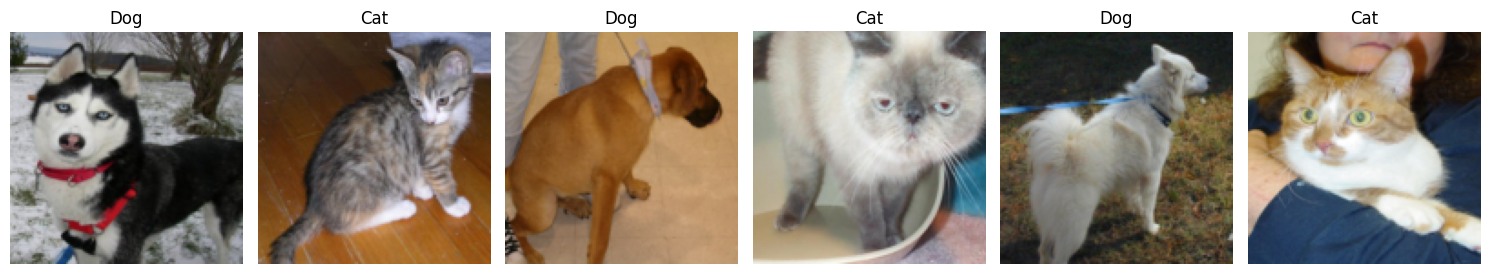

In [7]:
# Visualize some samples
fig, axes = plt.subplots(1, 6, figsize=(15, 4))

for i in range(6):
    # image, label = full_dataset[i]
    image, label = train_dataset[i] # using train dataset to visualize samples
    image_np = image.permute(1, 2, 0).numpy()

    axes[i].imshow(image_np)
    axes[i].set_title(full_dataset.classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Check a batch of data
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First 10 labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])
First 10 labels: tensor([1, 0, 1, 1, 1, 0, 1, 0, 1, 0])


In [ ]:
# Check class balance in each split: we want to make sure we have a good mix of cats and dogs in each split, otherwise our model might not learn properly
def count_labels(subset):
    counts = Counter()
    for _, label in subset:
        counts[label] += 1
    return counts

train_counts = count_labels(train_dataset)
val_counts = count_labels(val_dataset)
test_counts = count_labels(test_dataset)

idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

for split_name, counts in [("train", train_counts), ("val", val_counts), ("test", test_counts)]:
    print(split_name)
    for idx, count in counts.items():
        print(f"  {idx_to_class[idx]}: {count}")

/opt/miniconda3/envs/torch/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


train
  Dog: 10003
  Cat: 9995
val
  Cat: 1244
  Dog: 1255
test
  Dog: 1241
  Cat: 1260


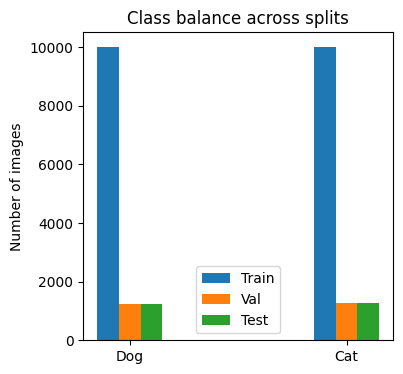

In [22]:
labels = [idx_to_class[i] for i in train_counts.keys()]

train_vals = [train_counts[i] for i in train_counts.keys()]
val_vals = [val_counts[i] for i in val_counts.keys()]
test_vals = [test_counts[i] for i in test_counts.keys()]

x = np.arange(len(labels))
width = 0.1

plt.figure(figsize=(4,4))

plt.bar(x - width, train_vals, width, label='Train')
plt.bar(x, val_vals, width, label='Val')
plt.bar(x + width, test_vals, width, label='Test')

plt.xticks(x, labels)
plt.ylabel("Number of images")
plt.title("Class balance across splits")
plt.legend()

plt.show()

Rougly balanced cats and dogs: OK!

## Define simple CNN

In [12]:
# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 128 -> 64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64 -> 32
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
# Instantiate the model and move it to the device
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


## One forward pass

In [13]:
# Check the model output shape
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print(outputs[:2])

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 2])
tensor([[-0.0786,  0.0752],
        [-0.0678,  0.0715]], device='mps:0', grad_fn=<SliceBackward0>)
